# **1. Perkenalan Dataset**


Pada eksperimen ini digunakan **Adult Income Dataset** yang berasal dari UCI Machine Learning Repository. Dataset ini berisi informasi demografis dan pekerjaan seseorang, seperti usia, tingkat pendidikan, status pernikahan, jenis pekerjaan, jam kerja per minggu, serta pendapatan.

Tujuan dari dataset ini adalah melakukan **klasifikasi** apakah seseorang memiliki pendapatan **lebih dari \$50.000 per tahun** atau **kurang atau sama dengan \$50.000 per tahun** berdasarkan karakteristik yang dimiliki.

Dataset terdiri atas 32.561 data dengan 15 atribut, di mana 14 atribut digunakan sebagai fitur (features) dan 1 atribut sebagai target (label), yaitu **income**.

Pada notebook ini akan dilakukan beberapa tahapan, yaitu:
1. Memuat dataset.
2. Melakukan eksplorasi data (EDA).
3. Melakukan data preprocessing.
4. Menghasilkan dataset yang siap digunakan pada proses pelatihan model machine learning.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Import Libraries

# Manipulasi Data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Utility
import warnings
warnings.filterwarnings("ignore")

# Pengaturan tampilan
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

# Style visualisasi
sns.set_style("whitegrid")

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:

# DATA LOADING

from google.colab import files
import os
import shutil
import pandas as pd

# Upload file hanya jika belum ada
if not os.path.exists("adult.data"):
    uploaded = files.upload()

# Simpan ke folder dataset agar lebih rapi
os.makedirs("dataset_raw", exist_ok=True)

if os.path.exists("adult.data"):
    shutil.copy("adult.data", "dataset_raw/adult.data")

# Nama kolom dataset Adult Income
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

# Membaca dataset
df = pd.read_csv(
    "dataset_raw/adult.data",
    header=None,
    names=columns,
    skipinitialspace=True,
    na_values="?"
)

print("Dataset berhasil dimuat")
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

df.head()

Saving adult.data to adult.data
Dataset berhasil dimuat
Jumlah baris : 32561
Jumlah kolom : 15


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# Exploratory Data Analysis (EDA)

print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
display(df.isnull().sum().to_frame(name="Jumlah Missing"))

print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF")
print("=" * 60)
display(df.describe())

print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF (KATEGORIKAL)")
print("=" * 60)
display(df.describe(include="object"))

print("\n" + "=" * 60)
print("DISTRIBUSI TARGET")
print("=" * 60)
display(df["income"].value_counts().to_frame(name="Jumlah"))

print("\nPersentase Target:")
display((df["income"].value_counts(normalize=True) * 100).round(2).to_frame(name="Persentase (%)"))

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

MISSING VALUES


,Jumlah Missing
age,0
workclass,1836
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,1843
relationship,0
race,0
sex,0



STATISTIK DESKRIPTIF


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000



STATISTIK DESKRIPTIF (KATEGORIKAL)


,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
count,30725,32561,32561,30718,32561,32561,32561,31978,32561
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720



DISTRIBUSI TARGET


,Jumlah
income,
<=50K,24720
>50K,7841



Persentase Target:


,Persentase (%)
income,
<=50K,75.92
>50K,24.08


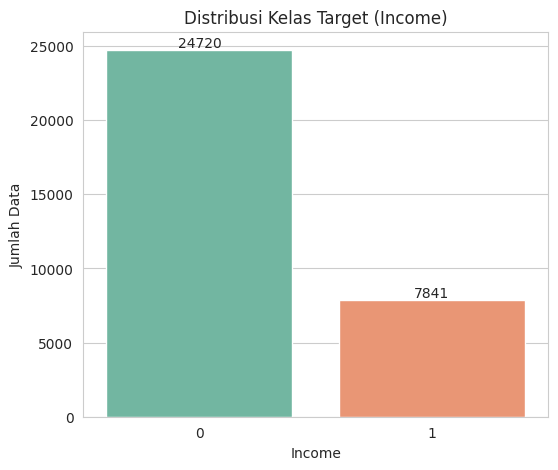


Persentase masing-masing kelas:


,Persentase (%)
income,
0,75.92
1,24.08


In [9]:
# Distribusi Target (Income)

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="income",
    palette="Set2"
)

plt.title("Distribusi Kelas Target (Income)")
plt.xlabel("Income")
plt.ylabel("Jumlah Data")

for container in plt.gca().containers:
    plt.bar_label(container)

plt.show()

print("\nPersentase masing-masing kelas:")
display(
    (df["income"].value_counts(normalize=True)*100)
    .round(2)
    .rename("Persentase (%)")
)

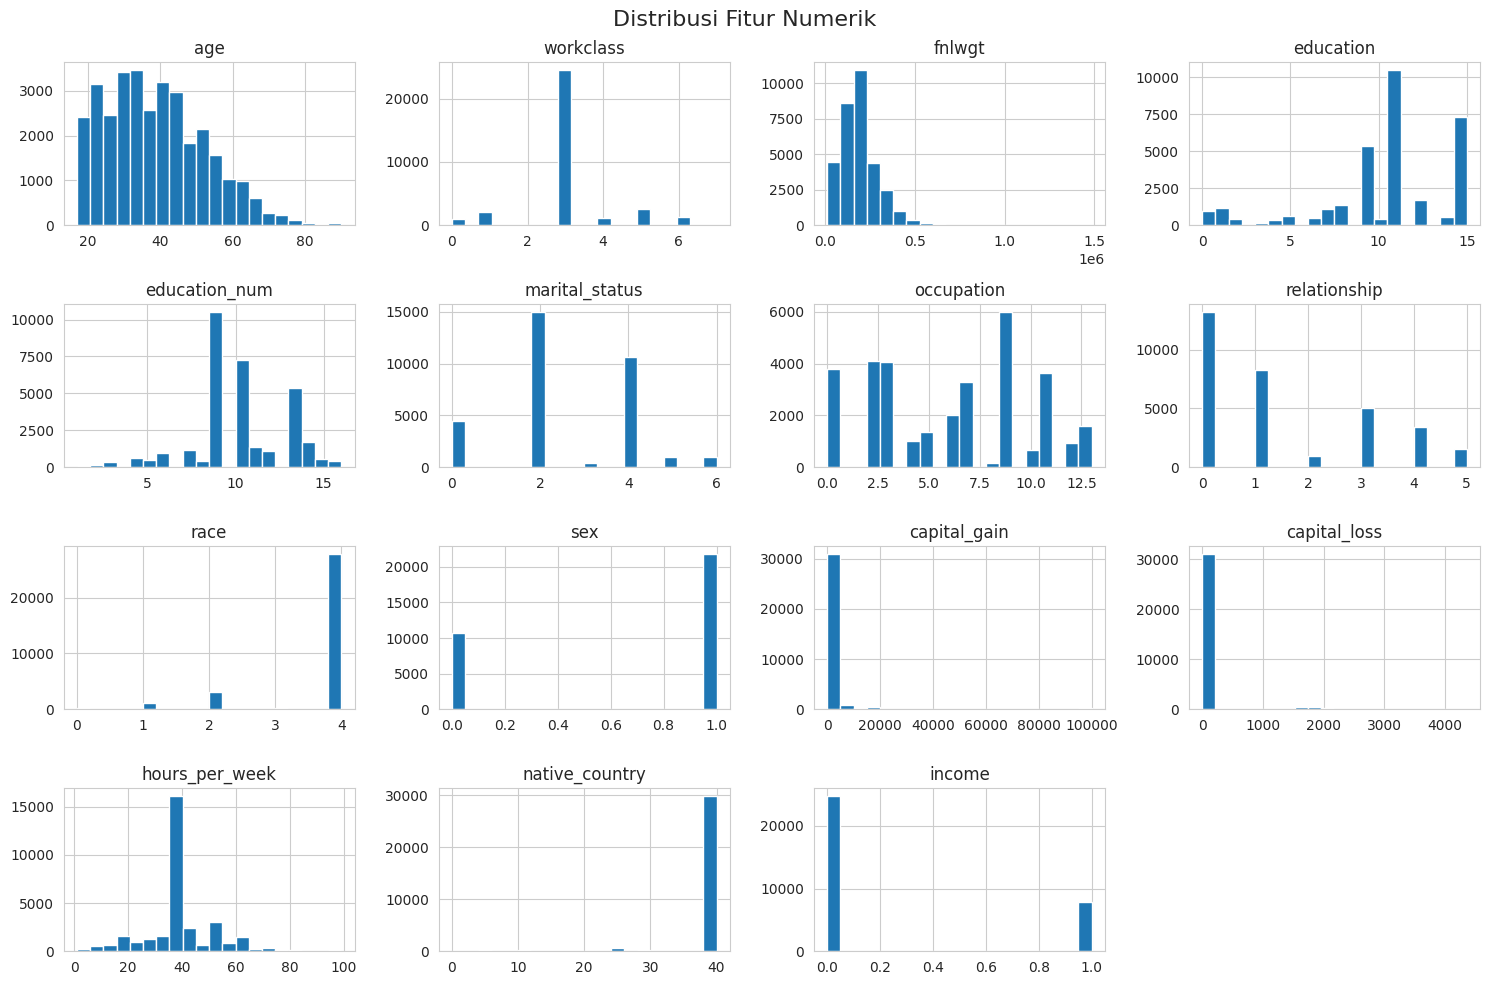

In [10]:
# Distribusi Fitur Numerik

numeric_columns = df.select_dtypes(include=["int64","float64"]).columns

df[numeric_columns].hist(
    figsize=(15,10),
    bins=20
)

plt.suptitle("Distribusi Fitur Numerik", fontsize=16)
plt.tight_layout()

plt.show()

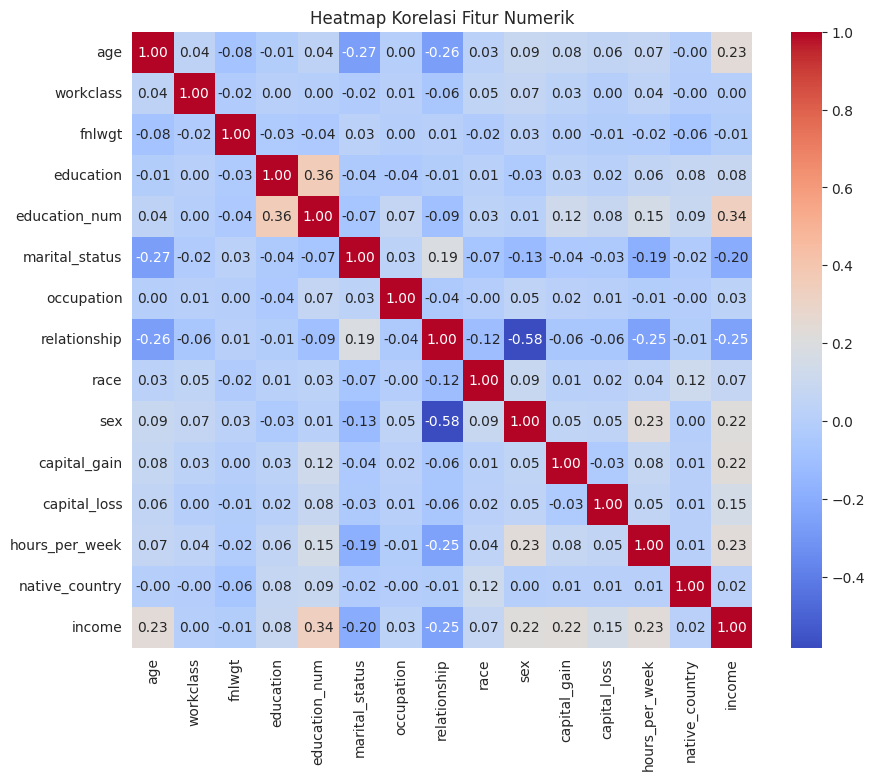

In [11]:
# Heatmap Korelasi

plt.figure(figsize=(10,8))

correlation = df.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Heatmap Korelasi Fitur Numerik")

plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# Mengecek missing value dan tipe data

print("===== Informasi Dataset =====")
print(df.info())

print("\n===== Missing Value =====")
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Jumlah Missing": missing,
    "Persentase (%)": (missing / len(df)) * 100
})

display(missing_df)

print("\nJumlah data duplikat :", df.duplicated().sum())

===== Informasi Dataset =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None

===== Missing Value =====


,Jumlah Missing,Persentase (%)
age,0,0.000000
workclass,1836,5.638647
fnlwgt,0,0.000000
education,0,0.000000
education_num,0,0.000000
marital_status,0,0.000000
occupation,1843,5.660146
relationship,0,0.000000
race,0,0.000000
sex,0,0.000000



Jumlah data duplikat : 24


In [5]:
# Menangani Missing Value

print("Jumlah missing value sebelum preprocessing:")
print(df.isnull().sum())

# Kolom numerik
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Kolom kategorikal
categorical_columns = df.select_dtypes(include=["object"]).columns

# Imputasi
numeric_imputer = SimpleImputer(strategy="median")
categorical_imputer = SimpleImputer(strategy="most_frequent")

df[numeric_columns] = numeric_imputer.fit_transform(df[numeric_columns])
df[categorical_columns] = categorical_imputer.fit_transform(df[categorical_columns])

print("\nJumlah missing value sesudah preprocessing:")
print(df.isnull().sum())

Jumlah missing value sebelum preprocessing:
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

Jumlah missing value sesudah preprocessing:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [6]:
# Encoding Data Kategorikal

label_encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])
    label_encoders[column] = encoder

print("Encoding selesai.")

df.head()

Encoding selesai.


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39.0,6,77516.0,9,13.0,4,0,1,4,1,2174.0,0.0,40.0,38,0
1,50.0,5,83311.0,9,13.0,2,3,0,4,1,0.0,0.0,13.0,38,0
2,38.0,3,215646.0,11,9.0,0,5,1,4,1,0.0,0.0,40.0,38,0
3,53.0,3,234721.0,1,7.0,2,5,0,2,1,0.0,0.0,40.0,38,0
4,28.0,3,338409.0,9,13.0,2,9,5,2,0,0.0,0.0,40.0,4,0


In [7]:
# Feature Scaling

# Pisahkan fitur dan target
X = df.drop("income", axis=1)
y = df["income"]

# Standardisasi fitur
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Kembalikan menjadi DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("Feature Scaling berhasil dilakukan.")

X_scaled.head()

Feature Scaling berhasil dilakukan.


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,0.030671,2.624298,-1.063611,-0.335437,1.134739,0.921634,-1.545256,-0.277805,0.393668,0.703071,0.148453,-0.21666,-0.035429,0.26137
1,0.837109,1.721100,-1.008707,-0.335437,1.134739,-0.406212,-0.790092,-0.900181,0.393668,0.703071,-0.145920,-0.21666,-2.222153,0.26137
2,-0.042642,-0.085296,0.245079,0.181332,-0.420060,-1.734058,-0.286649,-0.277805,0.393668,0.703071,-0.145920,-0.21666,-0.035429,0.26137
3,1.057047,-0.085296,0.425801,-2.402511,-1.197459,-0.406212,-0.286649,-0.900181,-1.962621,0.703071,-0.145920,-0.21666,-0.035429,0.26137
4,-0.775768,-0.085296,1.408176,-0.335437,1.134739,-0.406212,0.720237,2.211698,-1.962621,-1.422331,-0.145920,-0.21666,-0.035429,-5.35294


In [8]:
# MENYIMPAN DATASET HASIL PREPROCESSING

# Gabungkan kembali fitur dan target
df_preprocessed = X_scaled.copy()
df_preprocessed["income"] = y.values

# Simpan ke CSV
df_preprocessed.to_csv(
    "adult_preprocessed.csv",
    index=False
)

print("Dataset preprocessing berhasil disimpan.")
print("Ukuran dataset:", df_preprocessed.shape)

df_preprocessed.head()

Dataset preprocessing berhasil disimpan.
Ukuran dataset: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030671,2.624298,-1.063611,-0.335437,1.134739,0.921634,-1.545256,-0.277805,0.393668,0.703071,0.148453,-0.21666,-0.035429,0.26137,0
1,0.837109,1.721100,-1.008707,-0.335437,1.134739,-0.406212,-0.790092,-0.900181,0.393668,0.703071,-0.145920,-0.21666,-2.222153,0.26137,0
2,-0.042642,-0.085296,0.245079,0.181332,-0.420060,-1.734058,-0.286649,-0.277805,0.393668,0.703071,-0.145920,-0.21666,-0.035429,0.26137,0
3,1.057047,-0.085296,0.425801,-2.402511,-1.197459,-0.406212,-0.286649,-0.900181,-1.962621,0.703071,-0.145920,-0.21666,-0.035429,0.26137,0
4,-0.775768,-0.085296,1.408176,-0.335437,1.134739,-0.406212,0.720237,2.211698,-1.962621,-1.422331,-0.145920,-0.21666,-0.035429,-5.35294,0
